# Benchmark Charts

Đọc data từ `outputs/` => vẽ các chart cho việc biểu diễn trực quan các đánh giá.

### Load dữ liệu benchmark

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def resolve_eval_dir():
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "src" / "eval",
        cwd / "BE_ChatBot" / "src" / "eval",
    ]
    for candidate in candidates:
        if (candidate / "outputs").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy thư mục outputs/. Hãy mở notebook từ BE_ChatBot/src/eval hoặc D:/KLTN/Project.")


EVAL_DIR = resolve_eval_dir()
OUTPUT_DIR = EVAL_DIR / "outputs"


def load_json(name):
    with (OUTPUT_DIR / name).open("r", encoding="utf-8") as f:
        return json.load(f)


dataset = load_json("dataset_coverage.json")
retrieval = load_json("retrieval_results.json")
output_validity = load_json("output_validity_results.json")

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

palette = ["#3B82F6", "#10B981", "#F59E0B", "#EF4444", "#8B5CF6", "#14B8A6", "#64748B"]


def annotate_bars(ax, suffix="", decimals=0):
    for patch in ax.patches:
        value = patch.get_height()
        label = f"{value:.{decimals}f}{suffix}"
        ax.annotate(
            label,
            (patch.get_x() + patch.get_width() / 2, value),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 4),
            textcoords="offset points",
        )


def pct(value):
    return value * 100

In [2]:
runtime = retrieval.get("llm_runtime", {}) or output_validity.get("llm_runtime", {})
summary_rows = [
    ("Dataset places", dataset["summary"]["total_places"]),
    ("Retrieval cases", retrieval["case_count"]),
    ("Output cases", output_validity["case_count"]),
    ("Core LLM", f"{runtime.get('core_llm_provider')} / {runtime.get('core_llm_model')}"),
    ("Rewrite LLM", f"{runtime.get('rewrite_llm_provider')} / {runtime.get('rewrite_llm_model')}"),
    ("Reranker", f"{runtime.get('reranker_provider')} / {runtime.get('reranker_model')}"),
]
pd.DataFrame(summary_rows, columns=["Thông tin", "Giá trị"])

,Thông tin,Giá trị
0,Dataset places,600
1,Retrieval cases,18
2,Output cases,10
3,Core LLM,ollama_cloud / gemma4:cloud
4,Rewrite LLM,groq / llama-3.1-8b-instant
5,Reranker,cohere / rerank-v3.5


### Dataset Coverage by Region

Check input data có cân bằng giữa các vùng hay không. Với bộ dữ liệu hiện tại, mỗi vùng kỳ vọng có 100 địa điểm.

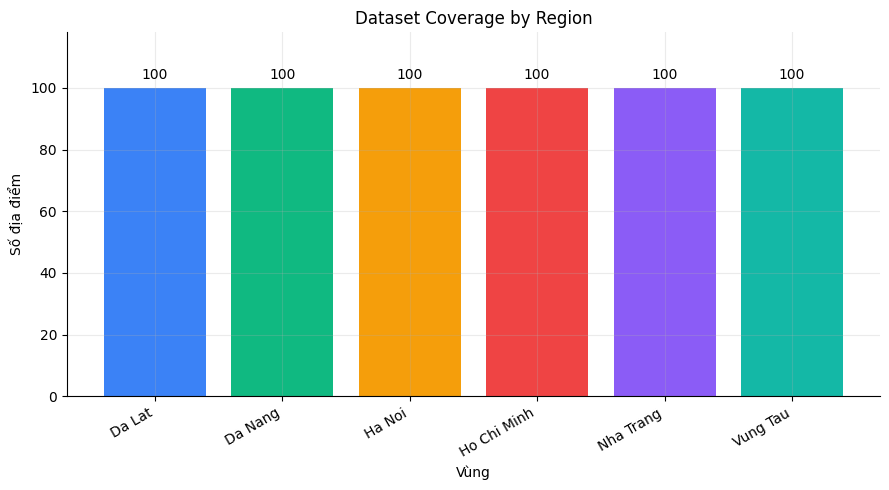

In [3]:
coverage_df = (
    pd.DataFrame(dataset["summary"]["places_by_region"].items(), columns=["Region", "Places"])
    .sort_values("Region")
    .reset_index(drop=True)
)

fig, ax = plt.subplots()
ax.bar(coverage_df["Region"], coverage_df["Places"], color=palette[: len(coverage_df)])
ax.set_title("Dataset Coverage by Region")
ax.set_ylabel("Số địa điểm")
ax.set_xlabel("Vùng")
ax.set_ylim(0, max(coverage_df["Places"]) * 1.18)
annotate_bars(ax)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Average Rating by Region

Mô tả chất lượng đánh giá trung bình theo vùng => Giải thích vì sao hệ thống có thể ưu tiên các địa điểm được đánh giá cao.

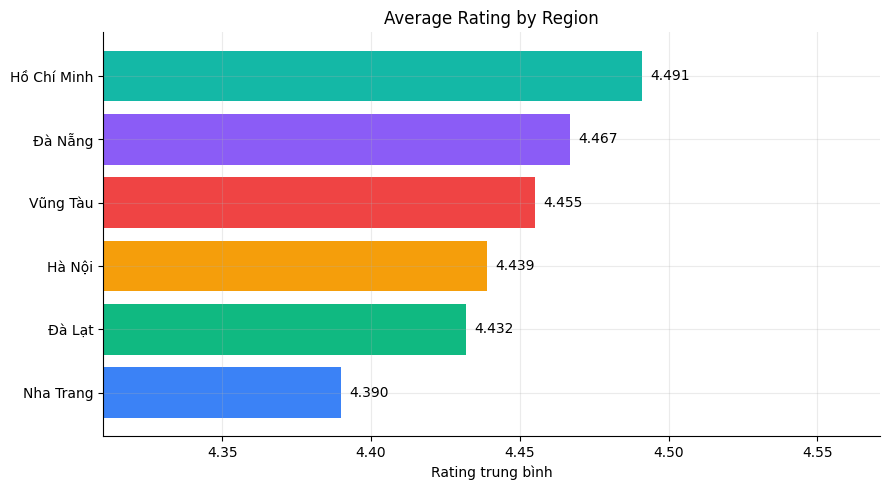

In [10]:
rating_df = (
    pd.DataFrame(dataset["summary"]["avg_rating_by_region"].items(), columns=["Region", "Average rating"])
    .sort_values("Average rating", ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots()
bars = ax.barh(rating_df["Region"], rating_df["Average rating"], color=palette[: len(rating_df)])
ax.set_title("Average Rating by Region")
ax.set_xlabel("Rating trung bình")
ax.set_xlim(max(0, rating_df["Average rating"].min() - 0.08), min(5, rating_df["Average rating"].max() + 0.08))
for bar in bars:
    value = bar.get_width()
    ax.annotate(f"{value:.3f}", (value, bar.get_y() + bar.get_height() / 2), va="center", xytext=(6, 0), textcoords="offset points")
plt.tight_layout()
plt.show()

### Precision@K

- Đo tỷ lệ tài liệu đúng trong top-K sau rerank => chỉ số trực quan nhất để chứng minh hệ thống đưa địa điểm phù hợp lên đầu danh sách.
- Công thức: Precision@K = số kết quả đúng trong top K / K
- Trong K kqua đầu tiên có bn đúng/liên quan. Ví dụ:
    - [Đúng, Sai, Đúng, Đúng, Sai] => Precision@5 = 3 / 5 = 60%
    - @K: xét top K kết quả đầu tiên. Ví dụ: Precision@3: Trong 3 kết quả đầu tiên, bao nhiêu kết quả đúng

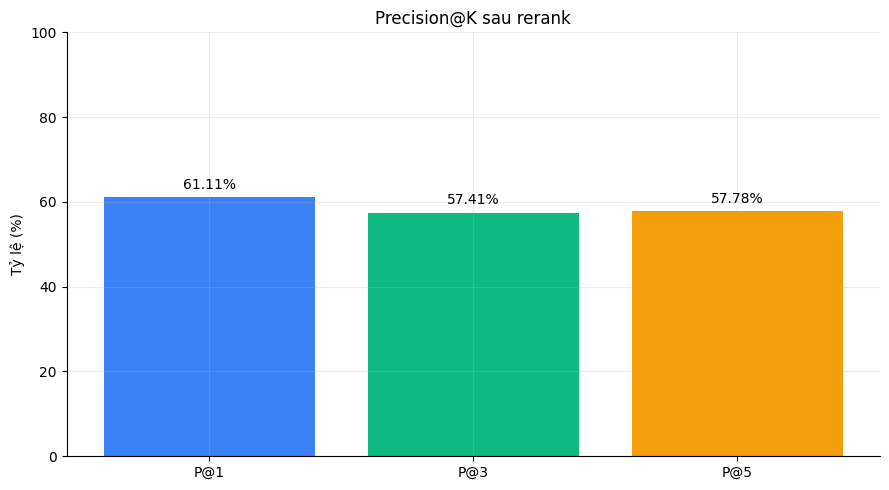

In [5]:
retrieval_results = retrieval["results"]
precision_metrics = ["precision@1", "precision@3", "precision@5"]
precision_after = [pct(sum(case["metrics_after_rerank"][metric] for case in retrieval_results) / len(retrieval_results)) for metric in precision_metrics]
precision_df = pd.DataFrame({"Metric": ["P@1", "P@3", "P@5"], "Value": precision_after})

fig, ax = plt.subplots()
ax.bar(precision_df["Metric"], precision_df["Value"], color=palette[:3])
ax.set_title("Precision@K sau rerank")
ax.set_ylabel("Tỷ lệ (%)")
ax.set_ylim(0, 100)
annotate_bars(ax, suffix="%", decimals=2)
plt.tight_layout()
plt.show()

### nDCG@5

- Đo chất lượng thứ hạng => document đúng đứng càng cao thì điểm càng tốt. 
- Dùng chung Precision@K để tránh chỉ đánh giá số lượng tài liệu đúng mà bỏ qua vị trí xếp hạng.
- Precision chỉ biết `đúng hay sai`, nhưng không quan tâm kết quả đúng nằm ở vị trí nào => nDCG thì có. Ví dụ:
    - Case A: [Đúng, Đúng, Sai, Sai, Sai]
    - Case B: [Sai, Sai, Sai, Đúng, Đúng]
    > - Cả 2 đều có Precision@5 = 2 / 5 = 40%
    > - Nhưng Case A tốt hơn, vì kết quả đúng nằm ở đầu. nDCG@5 sẽ cho Case A điểm cao hơn Case B.

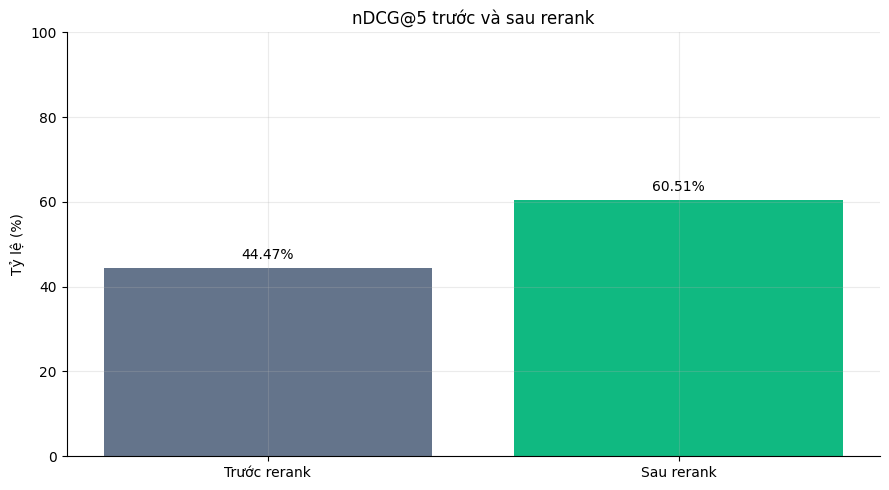

In [6]:
ndcg_before = pct(sum(case["metrics_before_rerank"]["ndcg@5"] for case in retrieval_results) / len(retrieval_results))
ndcg_after = pct(sum(case["metrics_after_rerank"]["ndcg@5"] for case in retrieval_results) / len(retrieval_results))
ndcg_df = pd.DataFrame({"Stage": ["Trước rerank", "Sau rerank"], "nDCG@5": [ndcg_before, ndcg_after]})

fig, ax = plt.subplots()
ax.bar(ndcg_df["Stage"], ndcg_df["nDCG@5"], color=["#64748B", "#10B981"])
ax.set_title("nDCG@5 trước và sau rerank")
ax.set_ylabel("Tỷ lệ (%)")
ax.set_ylim(0, 100)
annotate_bars(ax, suffix="%", decimals=2)
plt.tight_layout()
plt.show()

### Rerank Improvement

Compare trước - sau rerank ở các chỉ số retrieval chính => dùng để chứng minh reranker có cải thiện chất lượng truy xuất.

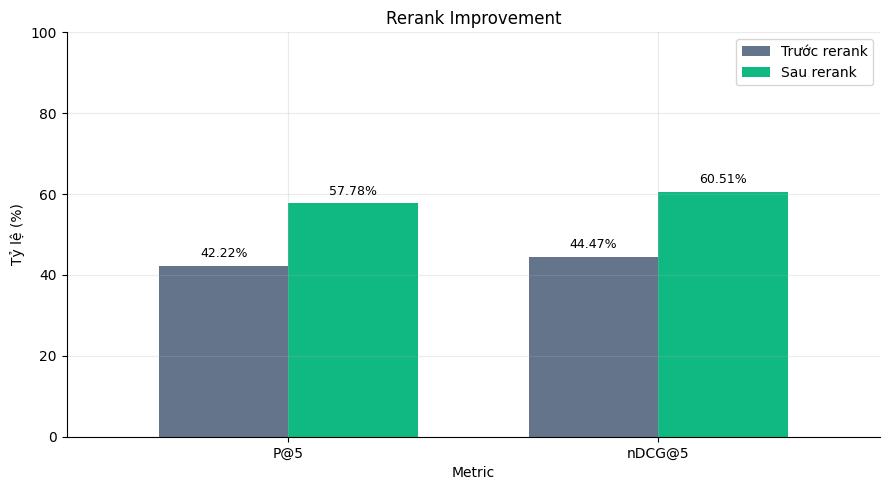

,Metric,Delta percentage points
0,P@5,15.555556
1,nDCG@5,16.036436


In [7]:
compare_metrics = ["precision@5", "ndcg@5"]
compare_labels = ["P@5", "nDCG@5"]
before_values = [pct(sum(case["metrics_before_rerank"][metric] for case in retrieval_results) / len(retrieval_results)) for metric in compare_metrics]
after_values = [pct(sum(case["metrics_after_rerank"][metric] for case in retrieval_results) / len(retrieval_results)) for metric in compare_metrics]
improve_df = pd.DataFrame({"Metric": compare_labels, "Trước rerank": before_values, "Sau rerank": after_values})

ax = improve_df.set_index("Metric").plot(kind="bar", color=["#64748B", "#10B981"], width=0.7)
ax.set_title("Rerank Improvement")
ax.set_ylabel("Tỷ lệ (%)")
ax.set_ylim(0, 100)
for patch in ax.patches:
    value = patch.get_height()
    ax.annotate(f"{value:.2f}%", (patch.get_x() + patch.get_width() / 2, value), ha="center", va="bottom", fontsize=9, xytext=(0, 4), textcoords="offset points")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

delta_df = pd.DataFrame({
    "Metric": compare_labels,
    "Delta percentage points": [after - before for before, after in zip(before_values, after_values)],
})
delta_df

### Output Validity Rates

Đo độ đúng của output lịch trình: đúng số ngày, đúng vùng và đủ field bắt buộc.

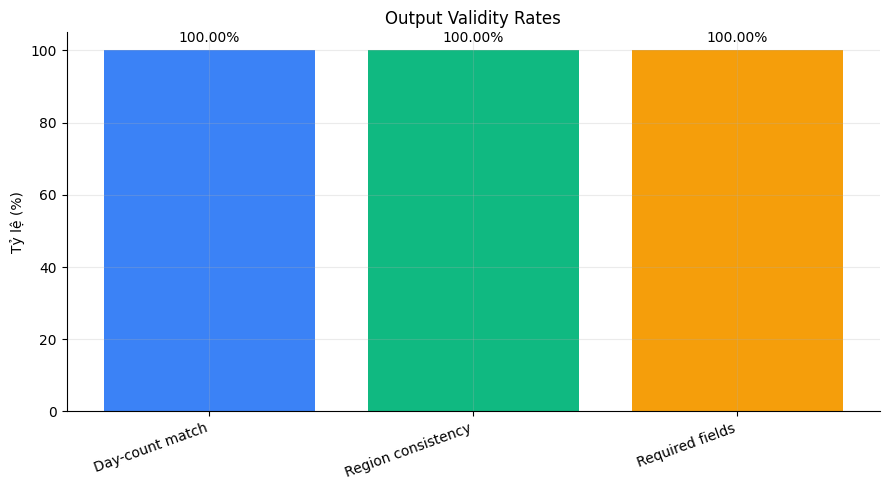

In [8]:
output_results = output_validity["results"]
validity_df = pd.DataFrame({
    "Metric": ["Day-count match", "Region consistency", "Required fields"],
    "Value": [
        pct(sum(case["day_count_match"] for case in output_results) / len(output_results)),
        pct(sum(case["region_consistent"] for case in output_results) / len(output_results)),
        pct(sum(case["required_field_completion_rate"] for case in output_results) / len(output_results)),
    ],
})

fig, ax = plt.subplots()
ax.bar(validity_df["Metric"], validity_df["Value"], color=palette[:3])
ax.set_title("Output Validity Rates")
ax.set_ylabel("Tỷ lệ (%)")
ax.set_ylim(0, 105)
annotate_bars(ax, suffix="%", decimals=2)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Latency Comparison

Tách latency retrieval/rerank và latency end-to-end vì hai nhóm có thang đo rất khác nhau. Retrieval và rerank ở mức dưới 1 giây, còn end-to-end bao gồm cả RAG và LLM sinh câu trả lời.

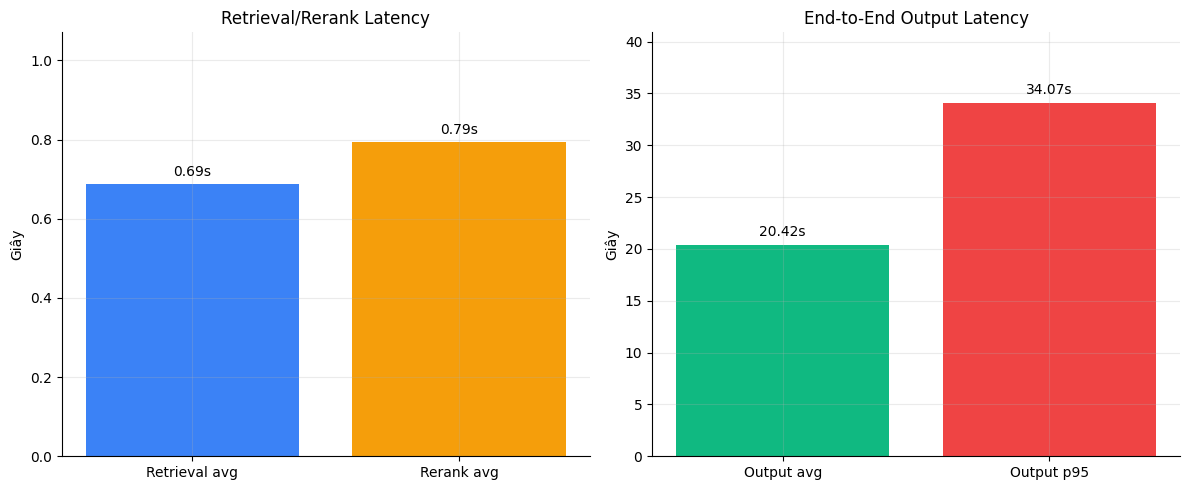

In [9]:
retrieval_latency_s = sum(case["retrieval_latency_ms"] for case in retrieval_results) / len(retrieval_results) / 1000
rerank_latency_s = sum(case["rerank_latency_ms"] for case in retrieval_results) / len(retrieval_results) / 1000
output_latencies_s = sorted(case["latency_ms"] / 1000 for case in output_results)
output_avg_s = sum(output_latencies_s) / len(output_latencies_s)
p95_index = int(0.95 * (len(output_latencies_s) - 1))
output_p95_s = output_latencies_s[p95_index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(["Retrieval avg", "Rerank avg"], [retrieval_latency_s, rerank_latency_s], color=["#3B82F6", "#F59E0B"])
axes[0].set_title("Retrieval/Rerank Latency")
axes[0].set_ylabel("Giây")
axes[0].set_ylim(0, max(retrieval_latency_s, rerank_latency_s) * 1.35)
for patch in axes[0].patches:
    value = patch.get_height()
    axes[0].annotate(f"{value:.2f}s", (patch.get_x() + patch.get_width() / 2, value), ha="center", va="bottom", xytext=(0, 4), textcoords="offset points")

axes[1].bar(["Output avg", "Output p95"], [output_avg_s, output_p95_s], color=["#10B981", "#EF4444"])
axes[1].set_title("End-to-End Output Latency")
axes[1].set_ylabel("Giây")
axes[1].set_ylim(0, max(output_avg_s, output_p95_s) * 1.2)
for patch in axes[1].patches:
    value = patch.get_height()
    axes[1].annotate(f"{value:.2f}s", (patch.get_x() + patch.get_width() / 2, value), ha="center", va="bottom", xytext=(0, 4), textcoords="offset points")

plt.tight_layout()
plt.show()

### Notes

- Output Validity hiện đang đo 10 case nếu benchmark được chạy với `--limit 10`.
- Retrieval ground truth hiện là pseudo ground truth theo rule region/tag/type, chưa phải nhãn do người đánh giá gán thủ công.
- Region consistency chỉ đối chiếu chắc chắn với các place name match được trong dataset.
- Runtime cần ghi rõ provider/model: core LLM, rewrite LLM và reranker để báo cáo có khả năng tái lập.